In [3]:
import torch
from torch import nn

torch.__version__

'2.12.1+cu130'

In [4]:
device = "cuda" if torch.cuda.is_available() else "illada kutta"
print(device)

cuda


In [5]:
!nvidia-smi

Mon Jul  6 14:20:47 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4050 ...    Off |   00000000:01:00.0 Off |                  N/A |
| N/A   46C    P8              2W /  115W |       5MiB /   6141MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
import requests
import zipfile
from pathlib import Path

#setup path to the data folder

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesnt exist, downoad it and prepare it...
if image_path.is_dir():
  print(f"{image_path}directory is already existing..skipping downlaoding")
else:
  print(f"No {image_path}. Creating one.....")
  image_path.mkdir(parents=True, exist_ok=True)



data/pizza_steak_sushidirectory is already existing..skipping downlaoding


In [7]:
# downlad pizza, steak and sushi data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
  print("Downloading Pizza, steak and sushi data..")
  f.write(request.content)

In [9]:
# unzip, lets fuckin do it
with zipfile.ZipFile("/home/ash/FoodVision/data/pizza_steak_sushi.zip","r") as zip_ref:
  print("Unzipping 3 of the data")
  zip_ref.extractall(image_path)

Unzipping 3 of the data


In [10]:
image_path

PosixPath('data/pizza_steak_sushi')

## 2. Becoming one with the data (Data preparation and data exploration)

In [14]:
import os
def walk_through_dir(dir_path):
  """ Walks through dir_path returning its contents. """

  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")

In [15]:
walk_through_dir(image_path)


There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi


In [16]:
# setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing an image


writing code to:
1. Get all the image paths

2.Pick a random image path using py random.choice()

3.Get the image class name

4. open the image with pythons pillow

5. show the image and print the metadata

Random image path is data/pizza_steak_sushi/test/pizza/2111981.jpg
Image class is pizza
Image height: 512
Image width: 512


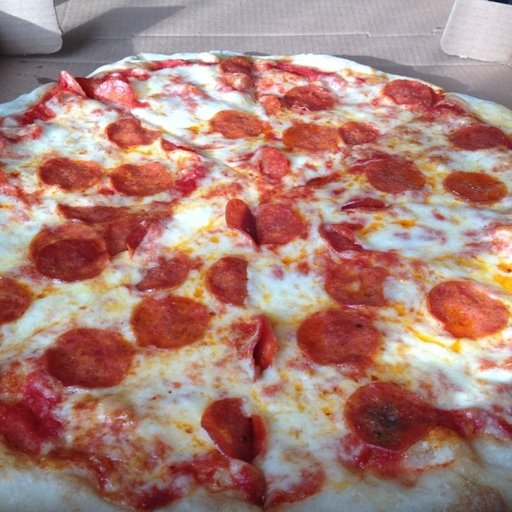

In [26]:
import random
from PIL import Image

#set seed
#random.seed(42)

#1. get all the image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))

#2. Pick a random image path
random_image_path = random.choice(image_path_list)

#3. Get the image class name
image_class = random_image_path.parent.stem

#4. Openup the image
img = Image.open(random_image_path)

#5. printing the metadata
print(f"Random image path is {random_image_path}")
print(f"Image class is {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

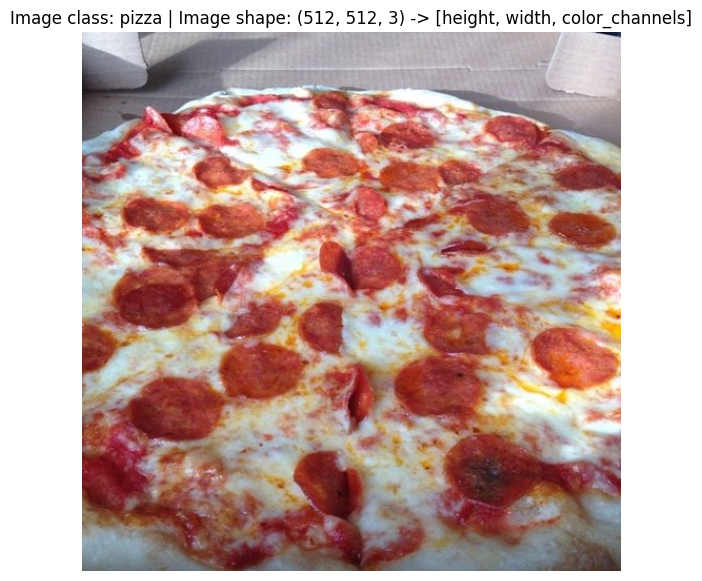

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)


#Plotting the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels]")
plt.axis(False);

##3. Transforming data

Before we can us e the img data with pytorch:
1. Turn your target data into tensors
2. Turn it into a torch.utils.data.Dataset and torch.utils.data.DataLoader, well call these dataset and dataloader

In [28]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with  'torchvision.transforms'